In [1]:
# Plot regional mortality box plot for one scenario for last decade per 100k

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from utils.utils import get_scenario_config

In [3]:
def load_regional_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [4]:
def process_mortality_per_100k(da):
    # === Path config ===
    MASK_DIR = "/glade/work/awells/air_quality/BMR/masks/region/"
    POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

    # === Load data ===
    mask_file = "GBD_Region_Masks_0.10.nc"
    mask_path = os.path.join(MASK_DIR, mask_file)
    mask = xr.open_dataarray(mask_path)

    pop_file = "ssp2_region_level_2000-2100.nc"
    pop_path = os.path.join(POP_DIR, pop_file)
    population = xr.open_dataarray(pop_path)
    pop = population.reindex_like(mask, method="nearest", tolerance=1e-9)

    # Calculate end of scenario mean (10 years)
    end_idx = da.sizes["year"]
    # Select the last 10 years
    da_last10 = da.isel(year=slice(end_idx - 10, end_idx))

    # Get the first and last time values
    start_time = da_last10.year[0].item()
    end_time = da_last10.year[-1].item()

    # Calculate ensemble and temporal mean
    da_mean = da_last10.mean(dim=("ensemble", "year"))

    # Calculate population mean
    years = slice(start_time, end_time)
    av_pop = pop.sel(year=years).mean("year")

    # Calculate mortality per 100,000
    da_per_100k = (da_mean/av_pop)*100000
    return da_per_100k, start_time, end_time

In [20]:
# === Plotting one scenario ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional/"

model = "UKESM1"
scenario = "SSP245_G6"

n_samples = 300

config = get_scenario_config(model, scenario)

da = load_regional_mortality_ensemble_members(model, scenario, config, n_samples)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


In [21]:
# Final 10 years per 100k
da_mean, first_year, last_year = process_mortality_per_100k(da)

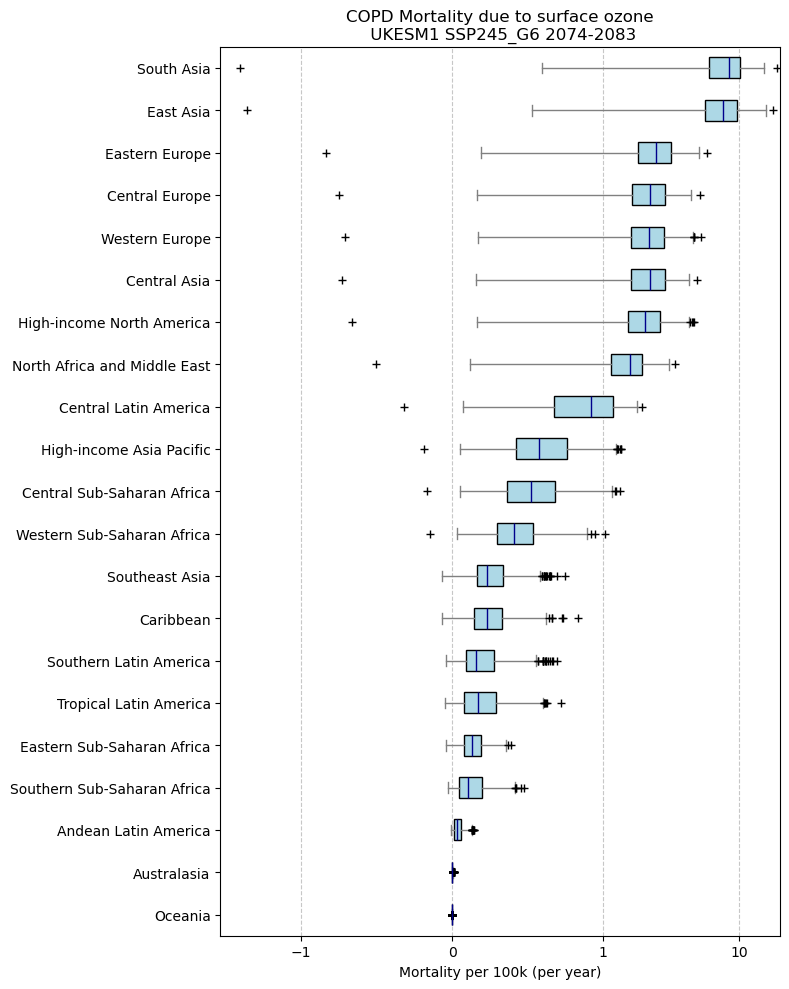

In [22]:
# Sort regions by mean value
region_means = da_mean.mean(dim="samples")
sorted_regions = region_means.sortby(region_means).region.values

data = [da_mean.sel(region=r).values for r in sorted_regions]

# --- Plot ---
plt.figure(figsize=(8, 10))
plt.boxplot(data, vert=False, patch_artist=True, sym='+',
            boxprops=dict(facecolor='lightblue', color='black'),
            medianprops=dict(color='darkblue'),
            whiskerprops=dict(color='gray'),
            capprops=dict(color='gray'))

plt.yticks(np.arange(1, len(sorted_regions) + 1), sorted_regions)
plt.xlabel("Mortality per 100k (per year)")
plt.title(f"COPD Mortality due to surface ozone\n {model} {scenario} {first_year}-{last_year}")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# --- Symmetric log scale with real-number tick labels ---
plt.xscale('symlog', linthresh=1)

# Use ScalarFormatter to show tick labels as real numbers
formatter = ScalarFormatter()
formatter.set_scientific(False)
plt.gca().xaxis.set_major_formatter(formatter)

out_file = f"Mortality_per_100k_region_boxplot_{model}_{scenario}_{first_year}-{last_year}.png"
out_path = os.path.join(SAVE_DIR, out_file)

plt.tight_layout()
plt.savefig(out_path)
plt.show()
